<a href="https://colab.research.google.com/github/marcebm19/BOOTCAMP-1/blob/Rama-Practica/correlacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

series de tiempo

In [8]:
import pandas as pd
import numpy as np

In [9]:
df_hurto_motos = pd.read_csv('/content/drive/MyDrive/hurto_de_moto.csv')
df_hurto_motos = pd.DataFrame(df_hurto_motos)
df_hurto_motos.head()

<ipython-input-9-97ca01a41e90>:1: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df_hurto_motos = pd.read_csv('/content/drive/MyDrive/hurto_de_moto.csv')


,fecha_hecho,cantidad,latitud,longitud,sexo,edad,estado_civil,grupo_actor,actividad_delictiva,parentesco,...,lugar,sede_receptora,bien,categoria_bien,grupo_bien,modelo,color,permiso,unidad_medida,fecha_ingestion
0,2017-01-01T23:00:00.000-05:00,1.0,6.268040,-75.549892,Hombre,29,Soltero(a),Sin dato,Sin dato,Sin dato,...,Vía pública,Manrique,Moto,Vehículos de 2 o 4 ruedas,Vehículo,2014,Azul,Sin dato,Sin dato,2024-10-06T04:04:55.000-05:00
1,2017-01-01T20:30:00.000-05:00,1.0,6.290076,-75.556893,Hombre,22,Unión marital de hecho,Sin dato,Sin dato,Sin dato,...,Vía pública,Santa Cruz,Moto,Vehículos de 2 o 4 ruedas,Vehículo,2005,Rojo,Sin dato,Sin dato,2024-10-06T04:04:55.000-05:00
2,2017-01-01T07:00:00.000-05:00,1.0,6.304187,-75.551760,Hombre,23,Unión marital de hecho,Sin dato,Sin dato,Sin dato,...,Vía pública,Santa Cruz,Moto,Vehículos de 2 o 4 ruedas,Vehículo,2011,Verde,Sin dato,Sin dato,2024-10-06T04:04:55.000-05:00
3,2017-01-01T09:00:00.000-05:00,1.0,6.248002,-75.574849,Hombre,-1,Sin dato,Sin dato,Sin dato,Sin dato,...,Almacén tienda y otro,Candelaria,Moto,Vehículos de 2 o 4 ruedas,Vehículo,-1,Negro,Sin dato,Sin dato,2024-10-06T04:04:55.000-05:00
4,2017-01-01T16:30:00.000-05:00,1.0,6.268129,-75.557882,Hombre,34,Soltero(a),Sin dato,Sin dato,Sin dato,...,Parqueadero,Aranjuez,Moto,Vehículos de 2 o 4 ruedas,Vehículo,2015,Negro,Sin dato,Sin dato,2024-10-06T04:04:55.000-05:00


In [10]:
##transformacion de fecha de hecho

In [11]:
df_fecha = pd.Series(df_hurto_motos['fecha_hecho'])
df_fecha

,fecha_hecho
0,2017-01-01T23:00:00.000-05:00
1,2017-01-01T20:30:00.000-05:00
2,2017-01-01T07:00:00.000-05:00
3,2017-01-01T09:00:00.000-05:00
4,2017-01-01T16:30:00.000-05:00
...,...
86405,2023-11-30T08:15:00.000-05:00
86406,2023-11-30T08:30:00.000-05:00
86407,2023-11-30T16:00:00.000-05:00
86408,2023-11-30T20:13:00.000-05:00


In [12]:
df_fecha = df_fecha.str.split('T')
df_fecha

,fecha_hecho
0,"[2017-01-01, 23:00:00.000-05:00]"
1,"[2017-01-01, 20:30:00.000-05:00]"
2,"[2017-01-01, 07:00:00.000-05:00]"
3,"[2017-01-01, 09:00:00.000-05:00]"
4,"[2017-01-01, 16:30:00.000-05:00]"
...,...
86405,"[2023-11-30, 08:15:00.000-05:00]"
86406,"[2023-11-30, 08:30:00.000-05:00]"
86407,"[2023-11-30, 16:00:00.000-05:00]"
86408,"[2023-11-30, 20:13:00.000-05:00]"


In [13]:
type(df_fecha)

pandas.core.series.Series

In [14]:
#separacion de fechas y horas

In [15]:
df_fecha = pd.DataFrame(df_fecha) # convierto de series de pandas a Dataframe
df_fecha = pd.DataFrame(df_fecha['fecha_hecho'].to_list(), columns = ['fecha','hora'])
df_fecha

,fecha,hora
0,2017-01-01,23:00:00.000-05:00
1,2017-01-01,20:30:00.000-05:00
2,2017-01-01,07:00:00.000-05:00
3,2017-01-01,09:00:00.000-05:00
4,2017-01-01,16:30:00.000-05:00
...,...,...
86405,2023-11-30,08:15:00.000-05:00
86406,2023-11-30,08:30:00.000-05:00
86407,2023-11-30,16:00:00.000-05:00
86408,2023-11-30,20:13:00.000-05:00


In [16]:
type(df_fecha)

pandas.core.frame.DataFrame

In [17]:
## transformo de dataframe a Datetime
df_fecha_datetime = pd.to_datetime(df_fecha['fecha'], format='%Y-%m-%d')
df_fecha_datetime

,fecha
0,2017-01-01
1,2017-01-01
2,2017-01-01
3,2017-01-01
4,2017-01-01
...,...
86405,2023-11-30
86406,2023-11-30
86407,2023-11-30
86408,2023-11-30


In [18]:
df_fecha_datetime.min()

Timestamp('2003-01-01 00:00:00')

In [19]:
df_fecha_datetime.max()

Timestamp('2023-11-30 00:00:00')

In [20]:
#identifico el mes de cada registro
df_fecha_datetime_mes = df_fecha_datetime.dt.month
df_fecha_datetime_mes

,fecha
0,1
1,1
2,1
3,1
4,1
...,...
86405,11
86406,11
86407,11
86408,11


In [21]:
df_fecha_datetime_dia = df_fecha_datetime.dt.day_name()
df_fecha_datetime_dia

,fecha
0,Sunday
1,Sunday
2,Sunday
3,Sunday
4,Sunday
...,...
86405,Thursday
86406,Thursday
86407,Thursday
86408,Thursday


In [22]:
import seaborn as sns ## libreria para graficas de estadistica
import matplotlib.pyplot as plt # libreria para uso general

In [23]:
df_fecha_datetime_dia = pd.DataFrame(df_fecha_datetime_dia)
df_fecha_datetime_dia


,fecha
0,Sunday
1,Sunday
2,Sunday
3,Sunday
4,Sunday
...,...
86405,Thursday
86406,Thursday
86407,Thursday
86408,Thursday


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Sunday'),
  Text(1, 0, 'Monday'),
  Text(2, 0, 'Tuesday'),
  Text(3, 0, 'Wednesday'),
  Text(4, 0, 'Thursday'),
  Text(5, 0, 'Friday'),
  Text(6, 0, 'Saturday')])

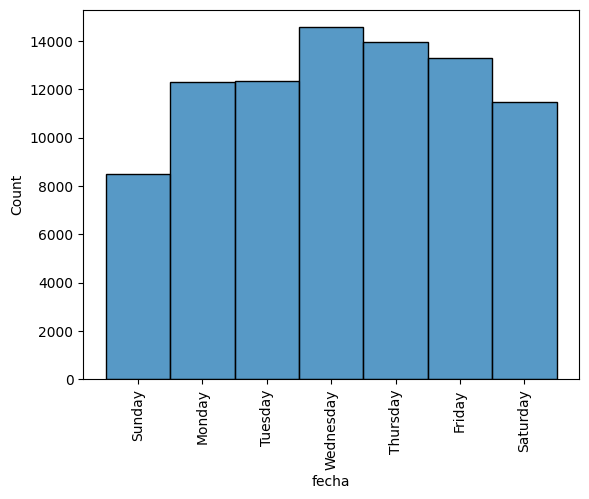

In [24]:
import seaborn as sns ## libreria para graficas de estadistica
import matplotlib.pyplot as plt # libreria para uso general


sns.histplot(data=df_fecha_datetime_dia, x="fecha", stat='count')
plt.xticks(rotation=90)



In [25]:
df_fecha_datetime_mes = df_fecha_datetime.dt.month_name()
df_fecha_datetime_mes

,fecha
0,January
1,January
2,January
3,January
4,January
...,...
86405,November
86406,November
86407,November
86408,November


In [26]:
df_fecha_datetime_mes = pd.DataFrame(df_fecha_datetime_mes)
df_fecha_datetime_mes


,fecha
0,January
1,January
2,January
3,January
4,January
...,...
86405,November
86406,November
86407,November
86408,November


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'January'),
  Text(1, 0, 'February'),
  Text(2, 0, 'March'),
  Text(3, 0, 'April'),
  Text(4, 0, 'May'),
  Text(5, 0, 'June'),
  Text(6, 0, 'July'),
  Text(7, 0, 'August'),
  Text(8, 0, 'September'),
  Text(9, 0, 'October'),
  Text(10, 0, 'November'),
  Text(11, 0, 'December')])

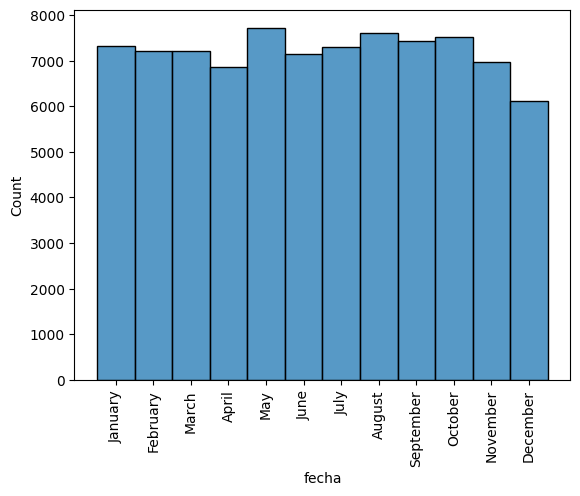

In [27]:
sns.histplot(data=df_fecha_datetime_mes, x="fecha", stat='count')
plt.xticks(rotation=90)

In [28]:
df_fecha_datetime_año = df_fecha_datetime.dt.year
df_fecha_datetime_año

,fecha
0,2017
1,2017
2,2017
3,2017
4,2017
...,...
86405,2023
86406,2023
86407,2023
86408,2023


In [29]:
df_fecha_datetime_año = pd.DataFrame(df_fecha_datetime_año)
df_fecha_datetime_año


,fecha
0,2017
1,2017
2,2017
3,2017
4,2017
...,...
86405,2023
86406,2023
86407,2023
86408,2023


(array([2000. , 2002.5, 2005. , 2007.5, 2010. , 2012.5, 2015. , 2017.5,
        2020. , 2022.5, 2025. ]),
 [Text(2000.0, 0, '2000.0'),
  Text(2002.5, 0, '2002.5'),
  Text(2005.0, 0, '2005.0'),
  Text(2007.5, 0, '2007.5'),
  Text(2010.0, 0, '2010.0'),
  Text(2012.5, 0, '2012.5'),
  Text(2015.0, 0, '2015.0'),
  Text(2017.5, 0, '2017.5'),
  Text(2020.0, 0, '2020.0'),
  Text(2022.5, 0, '2022.5'),
  Text(2025.0, 0, '2025.0')])

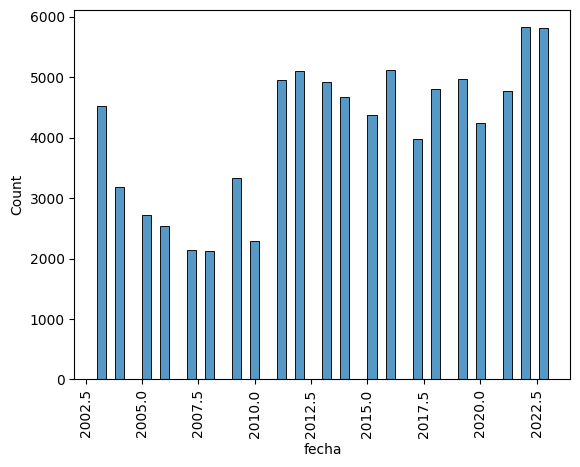

In [30]:
sns.histplot(data=df_fecha_datetime_año, x="fecha", stat='count')
plt.xticks(rotation=90)

In [31]:
df_fecha_agr = df_fecha.groupby("fecha").size()
df_fecha_agr

,0
fecha,
2003-01-01,10
2003-01-02,6
2003-01-03,8
2003-01-04,10
2003-01-05,6
...,...
2023-11-26,8
2023-11-27,9
2023-11-28,3


In [32]:
## como se relacionan los hechos, autocorrelación

<Figure size 1200x600 with 0 Axes>

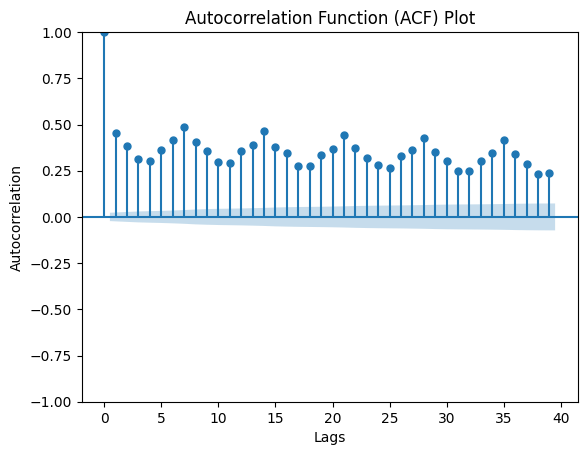

In [33]:
#calcular la autocorrelación de la serie de tiempo
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12, 6))
plot_acf(df_fecha_agr)
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Function (ACF) Plot')
plt.show()

In [34]:
df_hurto_motos.nombre_barrio = df_hurto_motos.nombre_barrio.str.lower()
df_hurto_motos.nombre_barrio

,nombre_barrio
0,el pomar
1,la rosa
2,la isla
3,guayaquil
4,manrique central no.1
...,...
86405,sin dato
86406,sin dato
86407,calasanz
86408,sin dato


In [35]:
#quitar espacios en blancon del final
df_hurto_motos.nombre_barrio = df_hurto_motos.nombre_barrio.str.strip()
df_hurto_motos.nombre_barrio


,nombre_barrio
0,el pomar
1,la rosa
2,la isla
3,guayaquil
4,manrique central no.1
...,...
86405,sin dato
86406,sin dato
86407,calasanz
86408,sin dato


In [36]:
barrios = df_hurto_motos.nombre_barrio.unique()
barrios

array(['el pomar', 'la rosa', 'la isla', 'guayaquil',
       'manrique central no.1', 'campo amor', 'pajarito',
       'trece de noviembre', 'aranjuez', 'san benito', 'estadio',
       'doce de octubre no.1', 'estación villa', 'caribe', 'moscú no.1',
       'san pablo', 'la cruz', 'tejelo', 'las acacias', 'aures no.2',
       'nueva villa del aburrá', 'miraflores', 'loreto', 'san diego',
       'corazón de jesús', 'andalucía', 'prado',
       'área urbana cgto. san antonio de prado', 'rosales',
       'campo valdés no.1', 'el chagualo', 'el danubio', 'miranda',
       'antonio nariño', 'el salvador', 'los ángeles', 'barrio colón',
       'área de expansión pajarito', 'trinidad', 'la mota', 'monteclaro',
       'villa carlota', 'bomboná no.2', 'las palmas', 'progreso',
       'cristo rey', 'bosques de san pablo', 'los conquistadores',
       'el diamante', 'villa nueva', 'área urbana cgto. san cristóbal',
       'castilla', 'el socorro', 'boyacá', 'santa fé', 'san joaquín',
       'sucr

In [37]:
barrios.sort()
barrios

array(['aguas frias', 'aldea pablo vi', 'alejandro echavarría',
       'alejandría', 'alfonso lópez', 'altamira', 'altavista',
       'altavista sector central', 'altos del poblado', 'andalucía',
       'antonio nariño', 'aranjuez', 'asomadera no.1', 'asomadera no.2',
       'asomadera no.3', 'astorga', 'aures no.1', 'aures no.2',
       'b. cerro el volador', 'barrio caycedo', 'barrio colombia',
       'barrio colón', 'barrio cristóbal', 'barrios de jesús',
       'barro blanco', 'batallón cuarta brigada', 'batallón girardot',
       'belalcázar', 'belencito', 'bello horizonte', 'belén', 'berlin',
       'bermejal-los alamos', 'betania', 'blanquizal', 'bolivariana',
       'bomboná no.1', 'bomboná no.2', 'boqueron', 'bosques de san pablo',
       'boston', 'boyacá', 'brasilia', 'buenos aires',
       'buga patio bonito', 'calasania parte alta', 'calasanz',
       'calle nueva', 'campo alegre', 'campo amor', 'campo valdés no.1',
       'campo valdés no.2', 'caribe', 'carlos e. restrepo

In [38]:
#importo librerias para identificar registros similares
!pip install fuzzywuzzy

In [39]:
## Importo librerias

In [40]:
import fuzzywuzzy
from fuzzywuzzy import process
import chardet

/usr/local/lib/python3.11/dist-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [41]:
matches = fuzzywuzzy.process.extract("sin dato", barrios, limit=10, scorer=fuzzywuzzy.fuzz.token_sort_ratio)
matches

[('sin dato', 100),
 ('sin dato 16 belen', 64),
 ('san antonio', 63),
 ('sin dato 7 robledo', 62),
 ('la mansión', 59),
 ('san diego', 59),
 ('san pablo', 59),
 ('san pedro', 59),
 ('sin dato 3 manrique', 59),
 ('sin dato 50 palmitas', 57)]

In [42]:
pd.DataFrame = df_hurto_motos.nombre_barrio
df_hurto_motos.nombre_barrio.unique()

array(['el pomar', 'la rosa', 'la isla', 'guayaquil',
       'manrique central no.1', 'campo amor', 'pajarito',
       'trece de noviembre', 'aranjuez', 'san benito', 'estadio',
       'doce de octubre no.1', 'estación villa', 'caribe', 'moscú no.1',
       'san pablo', 'la cruz', 'tejelo', 'las acacias', 'aures no.2',
       'nueva villa del aburrá', 'miraflores', 'loreto', 'san diego',
       'corazón de jesús', 'andalucía', 'prado',
       'área urbana cgto. san antonio de prado', 'rosales',
       'campo valdés no.1', 'el chagualo', 'el danubio', 'miranda',
       'antonio nariño', 'el salvador', 'los ángeles', 'barrio colón',
       'área de expansión pajarito', 'trinidad', 'la mota', 'monteclaro',
       'villa carlota', 'bomboná no.2', 'las palmas', 'progreso',
       'cristo rey', 'bosques de san pablo', 'los conquistadores',
       'el diamante', 'villa nueva', 'área urbana cgto. san cristóbal',
       'castilla', 'el socorro', 'boyacá', 'santa fé', 'san joaquín',
       'sucr

In [43]:
type(df_hurto_motos)

pandas.core.frame.DataFrame

In [44]:
df_hurto_motos.nombre_barrio.replace('sin dato 10 la candelaria','la candelaria',inplace=True)
df_hurto_motos.nombre_barrio.replace('sin dato 13 san javier','san javier',inplace=True)
df_hurto_motos.nombre_barrio.replace('sin dato 16 belen','belen',inplace=True)
df_hurto_motos.nombre_barrio.replace('sin dato 3 manrique','manrique',inplace=True)
df_hurto_motos.nombre_barrio.replace('sin dato 50 palmitas','palmitas',inplace=True)
df_hurto_motos.nombre_barrio.replace('sin dato 6 doce de octubre','doce de octubre',inplace=True)
df_hurto_motos.nombre_barrio.replace('sin dato 60 san cristobal','san cristobal',inplace=True)
df_hurto_motos.nombre_barrio.replace('sin dato 7 robledo','robledo',inplace=True)
df_hurto_motos.nombre_barrio.replace('sin dato 80 san antonio de prado','san antonio de prado',inplace=True)
df_hurto_motos.nombre_barrio.replace('sin dato 90 santa elena','santa elena',inplace=True)
df_hurto_motos.nombre_barrio.replace('facultad de minas u. nal','facultad de minas u. nacional',inplace=True)

In [45]:
barrios = df_hurto_motos.nombre_barrio.unique()
barrios

array(['el pomar', 'la rosa', 'la isla', 'guayaquil',
       'manrique central no.1', 'campo amor', 'pajarito',
       'trece de noviembre', 'aranjuez', 'san benito', 'estadio',
       'doce de octubre no.1', 'estación villa', 'caribe', 'moscú no.1',
       'san pablo', 'la cruz', 'tejelo', 'las acacias', 'aures no.2',
       'nueva villa del aburrá', 'miraflores', 'loreto', 'san diego',
       'corazón de jesús', 'andalucía', 'prado',
       'área urbana cgto. san antonio de prado', 'rosales',
       'campo valdés no.1', 'el chagualo', 'el danubio', 'miranda',
       'antonio nariño', 'el salvador', 'los ángeles', 'barrio colón',
       'área de expansión pajarito', 'trinidad', 'la mota', 'monteclaro',
       'villa carlota', 'bomboná no.2', 'las palmas', 'progreso',
       'cristo rey', 'bosques de san pablo', 'los conquistadores',
       'el diamante', 'villa nueva', 'área urbana cgto. san cristóbal',
       'castilla', 'el socorro', 'boyacá', 'santa fé', 'san joaquín',
       'sucr

In [46]:
barrios.sort()
barrios

array(['aguas frias', 'aldea pablo vi', 'alejandro echavarría',
       'alejandría', 'alfonso lópez', 'altamira', 'altavista',
       'altavista sector central', 'altos del poblado', 'andalucía',
       'antonio nariño', 'aranjuez', 'asomadera no.1', 'asomadera no.2',
       'asomadera no.3', 'astorga', 'aures no.1', 'aures no.2',
       'b. cerro el volador', 'barrio caycedo', 'barrio colombia',
       'barrio colón', 'barrio cristóbal', 'barrios de jesús',
       'barro blanco', 'batallón cuarta brigada', 'batallón girardot',
       'belalcázar', 'belen', 'belencito', 'bello horizonte', 'belén',
       'berlin', 'bermejal-los alamos', 'betania', 'blanquizal',
       'bolivariana', 'bomboná no.1', 'bomboná no.2', 'boqueron',
       'bosques de san pablo', 'boston', 'boyacá', 'brasilia',
       'buenos aires', 'buga patio bonito', 'calasania parte alta',
       'calasanz', 'calle nueva', 'campo alegre', 'campo amor',
       'campo valdés no.1', 'campo valdés no.2', 'caribe',
       'ca

In [47]:
matches = fuzzywuzzy.process.extract("sin dato cale", barrios, limit=10, scorer=fuzzywuzzy.fuzz.token_sort_ratio)
matches

[('sin dato', 76),
 ('sin dato 9 buenos aires', 61),
 ('aldea pablo vi', 59),
 ('calasanz', 57),
 ('pajarito s.c.', 56),
 ('la mansión', 55),
 ('los alpes', 55),
 ('san pablo', 55),
 ('san pedro', 55),
 ('san benito', 52)]

In [4]:
import pandas as pd
import numpy as np

In [5]:
df_hurto_personas = pd.read_csv('/content/drive/MyDrive/hurto_a_persona.csv')
df_hurto_personas = pd.DataFrame(df_hurto_personas) # Changed df to df_hurto_personas
df_hurto_personas.head()

<ipython-input-5-e2613ba80c45>:1: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df_hurto_personas = pd.read_csv('/content/drive/MyDrive/hurto_a_persona.csv')


,fecha_hecho,cantidad,latitud,longitud,sexo,edad,estado_civil,grupo_actor,actividad_delictiva,parentesco,...,lugar,sede_receptora,bien,categoria_bien,grupo_bien,modelo,color,permiso,unidad_medida,fecha_ingestion
0,2017-01-01T01:00:00.000-05:00,1.0,6.299703,-75.582016,Mujer,33,Unión marital de hecho,Sin dato,Sin dato,Sin dato,...,Vía pública,Doce de Octubre,Celular,Tecnología,Mercancía,-1,Sin dato,Sin dato,Sin dato,2024-10-06T04:07:03.000-05:00
1,2017-01-01T15:00:00.000-05:00,1.0,6.250917,-75.566160,Mujer,26,Soltero(a),Sin dato,Sin dato,Sin dato,...,Vía pública,Candelaria,Celular,Tecnología,Mercancía,-1,Sin dato,Sin dato,Sin dato,2024-10-06T04:07:03.000-05:00
2,2017-01-01T14:00:00.000-05:00,1.0,6.274836,-75.554909,Hombre,30,Soltero(a),Sin dato,Sin dato,Sin dato,...,Vía pública,Aranjuez,Celular,Tecnología,Mercancía,-1,Negro,Sin dato,Sin dato,2024-10-06T04:07:03.000-05:00
3,2017-01-01T16:00:00.000-05:00,1.0,6.276236,-75.553533,Hombre,37,Casado(a),Sin dato,Sin dato,Sin dato,...,Vía pública,Aranjuez,Celular,Tecnología,Mercancía,-1,Negro,Sin dato,Sin dato,2024-10-06T04:07:03.000-05:00
4,2017-01-01T16:00:00.000-05:00,1.0,6.250339,-75.586914,Hombre,87,Casado(a),Sin dato,Sin dato,Sin dato,...,Vía pública,Laureles,Billetera,Prendas de vestir y accesorios,Mercancía,-1,Sin dato,Sin dato,Sin dato,2024-10-06T04:07:03.000-05:00


(array([4.76800e+03, 5.82010e+04, 1.36697e+05, 7.47020e+04, 3.62320e+04,
        1.33920e+04, 2.27400e+03, 2.20000e+02, 0.00000e+00, 3.00000e+00]),
 array([ -1. ,  11.2,  23.4,  35.6,  47.8,  60. ,  72.2,  84.4,  96.6,
        108.8, 121. ]),
 <BarContainer object of 10 artists>)

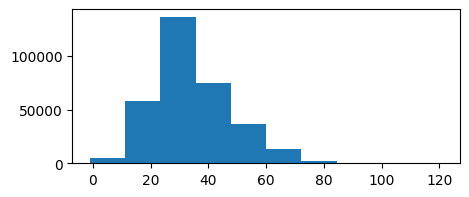

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(5, 2))
plt.hist(df_hurto_personas["edad"])

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Caminata'),
  Text(1, 0, 'Taxi'),
  Text(2, 0, 'Motocicleta'),
  Text(3, 0, 'Automóvil'),
  Text(4, 0, 'Metro'),
  Text(5, 0, 'Bicicleta'),
  Text(6, 0, 'Autobus'),
  Text(7, 0, 'Motocicleta con parrillero'),
  Text(8, 0, 'Sin dato'),
  Text(9, 0, 'Planeador')])

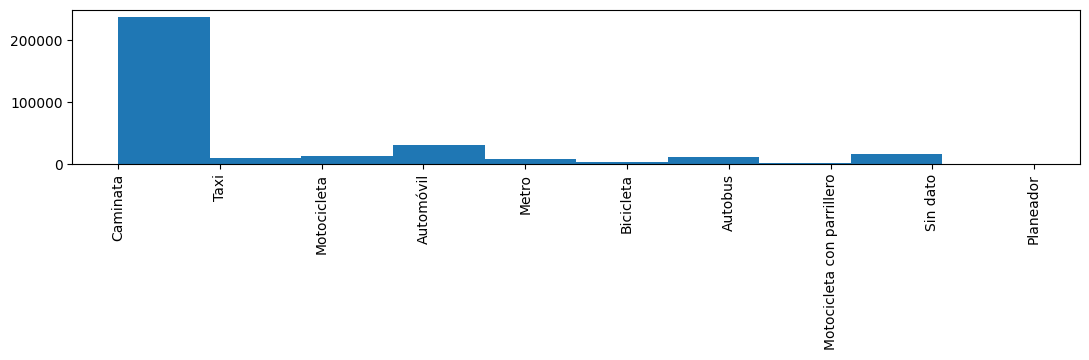

In [10]:
plt.figure(figsize=(13, 2)) # configuro el tamaño del grafico
plt.hist(df_hurto_personas["medio_transporte"]) # le aplico el histograma a la columna
plt.xticks(rotation = 90) #rotar etiquetas del eje x

(array([     0.,  50000., 100000., 150000., 200000., 250000., 300000.]),
 [Text(0.0, 0, '0'),
  Text(50000.0, 0, '50000'),
  Text(100000.0, 0, '100000'),
  Text(150000.0, 0, '150000'),
  Text(200000.0, 0, '200000'),
  Text(250000.0, 0, '250000'),
  Text(300000.0, 0, '300000')])

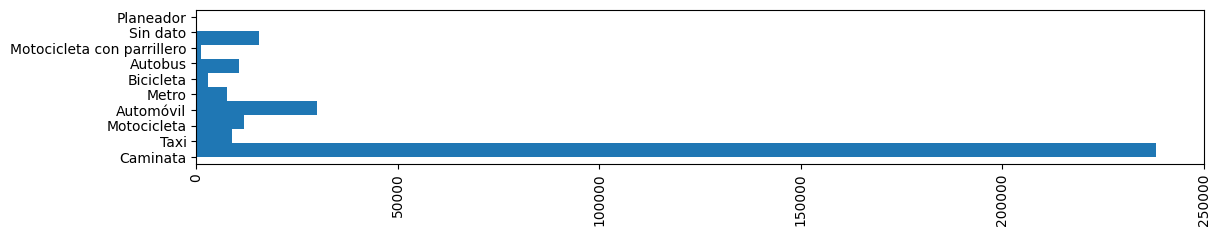

In [11]:
plt.figure(figsize=(13, 2)) # configuro el tamaño del grafico
plt.hist(df_hurto_personas["medio_transporte"],orientation= 'horizontal') # le aplico el histograma a la columna
plt.xticks(rotation = 90) #rotar etiquetas del eje x

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Caminata'),
  Text(1, 0, 'Taxi'),
  Text(2, 0, 'Motocicleta'),
  Text(3, 0, 'Automóvil'),
  Text(4, 0, 'Metro'),
  Text(5, 0, 'Bicicleta'),
  Text(6, 0, 'Autobus'),
  Text(7, 0, 'Motocicleta con parrillero'),
  Text(8, 0, 'Sin dato'),
  Text(9, 0, 'Planeador')])

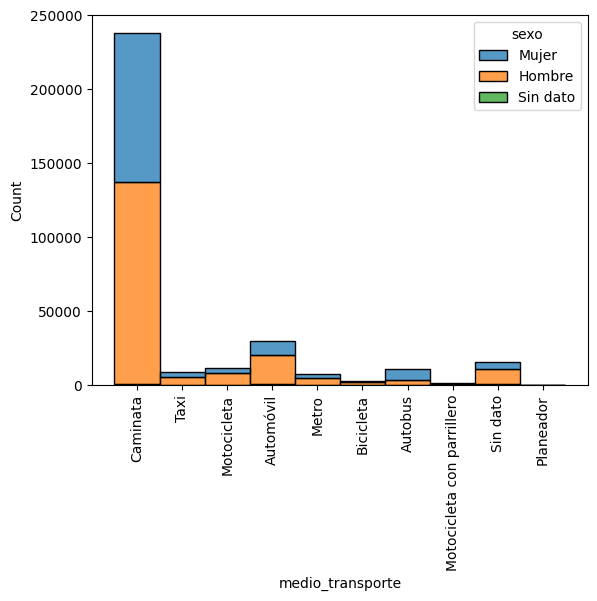

In [12]:
##crear histograma por medio de transporte
import seaborn as sns
sns.histplot(data=df_hurto_personas, x="medio_transporte", hue="sexo", multiple="stack")
plt.xticks(rotation=90)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Caminata'),
  Text(1, 0, 'Taxi'),
  Text(2, 0, 'Motocicleta'),
  Text(3, 0, 'Automóvil'),
  Text(4, 0, 'Metro'),
  Text(5, 0, 'Bicicleta'),
  Text(6, 0, 'Autobus'),
  Text(7, 0, 'Motocicleta con parrillero'),
  Text(8, 0, 'Sin dato'),
  Text(9, 0, 'Planeador')])

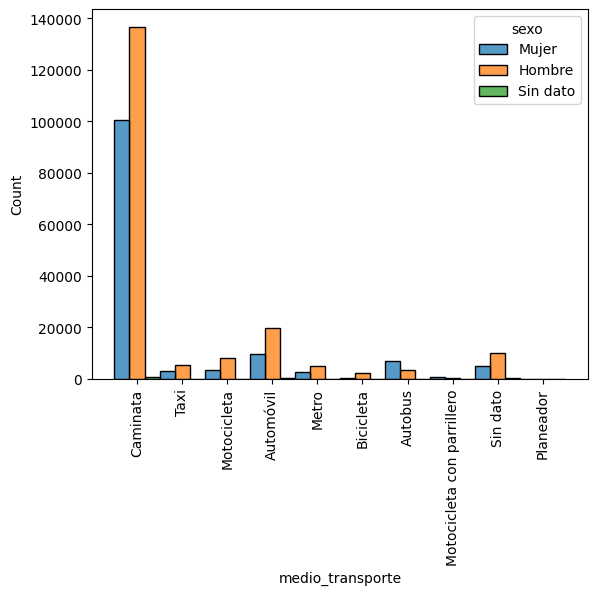

In [13]:
##crear histograma por medio de transporte
import seaborn as sns
sns.histplot(data=df_hurto_personas, x="medio_transporte", hue="sexo", multiple="dodge")
plt.xticks(rotation=90)

(array([-20.,   0.,  20.,  40.,  60.,  80., 100., 120., 140.]),
 [Text(-20.0, 0, '−20'),
  Text(0.0, 0, '0'),
  Text(20.0, 0, '20'),
  Text(40.0, 0, '40'),
  Text(60.0, 0, '60'),
  Text(80.0, 0, '80'),
  Text(100.0, 0, '100'),
  Text(120.0, 0, '120'),
  Text(140.0, 0, '140')])

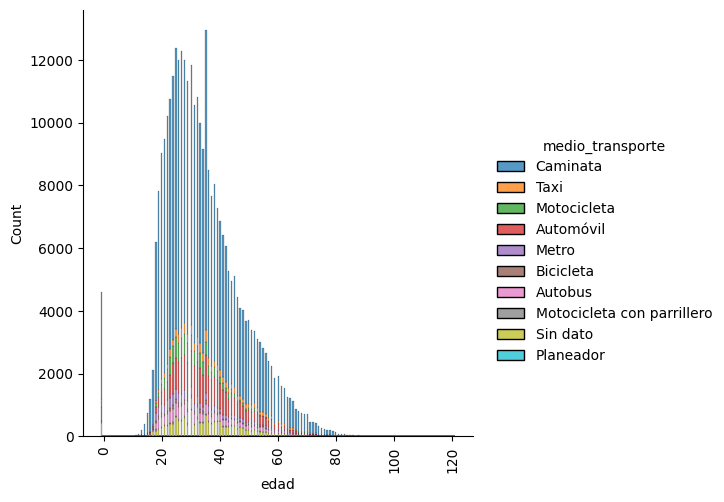

In [14]:
sns.displot(data=df_hurto_personas, x="edad", hue="medio_transporte", multiple="stack")
plt.xticks(rotation=90)

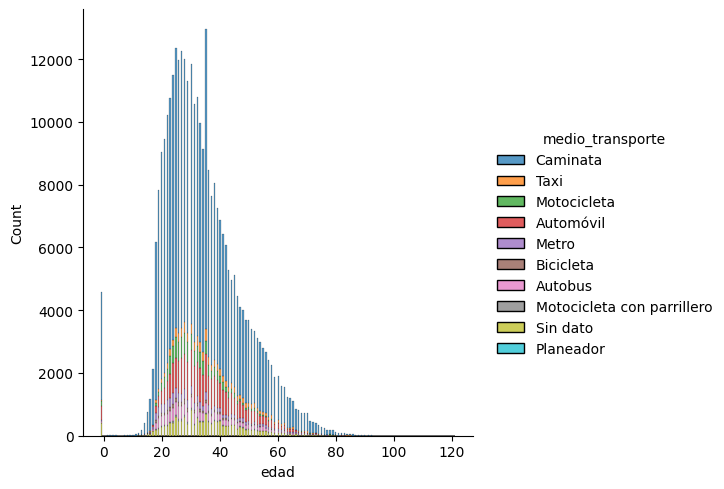

In [15]:
sns.displot(data=df_hurto_personas,
            x="edad",
            hue="medio_transporte",
            multiple="stack")
plt.savefig("edad_medio_transporte.svg") ## guardar en un formato de alta definicion

<ipython-input-16-ef246bcf513e>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


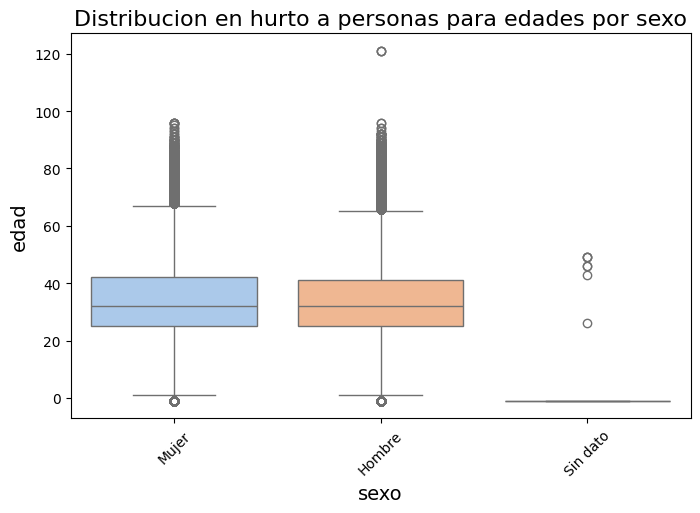

<Figure size 640x480 with 0 Axes>

In [16]:
import pandas as pd # Import the pandas library and assign it to the 'pd' alias
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(
    x=df_hurto_personas["sexo"],
    y=df_hurto_personas["edad"],
    palette= "pastel")
plt.title(
    'Distribucion en hurto a personas para edades por sexo',
     fontsize=16)
plt.xlabel(
    'sexo',
    fontsize=14)
plt.ylabel(
    'edad',
    fontsize=14)
plt.xticks(rotation=45)
plt.show()
plt.savefig("dist_sexo_edad.svg")



<ipython-input-18-e0806395a71f>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


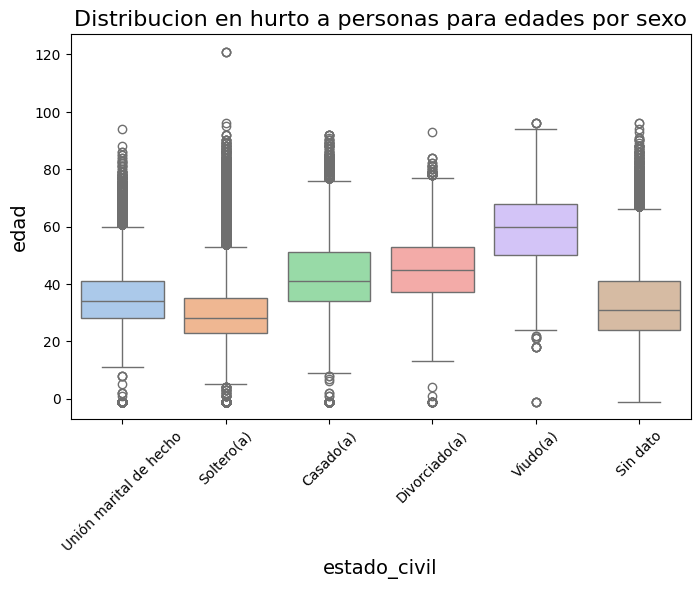

<Figure size 640x480 with 0 Axes>

In [18]:
import pandas as pd # Import the pandas library and assign it to the 'pd' alias
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(
    x=df_hurto_personas["estado_civil"],
    y=df_hurto_personas["edad"],
    palette= "pastel")
plt.title(
    'Distribucion en hurto a personas para edades por sexo',
     fontsize=16)
plt.xlabel(
    'estado_civil',
    fontsize=14)
plt.ylabel(
    'edad',
    fontsize=14)
plt.xticks(rotation=45)
plt.show()
plt.savefig("dist_estado_civil.svg")



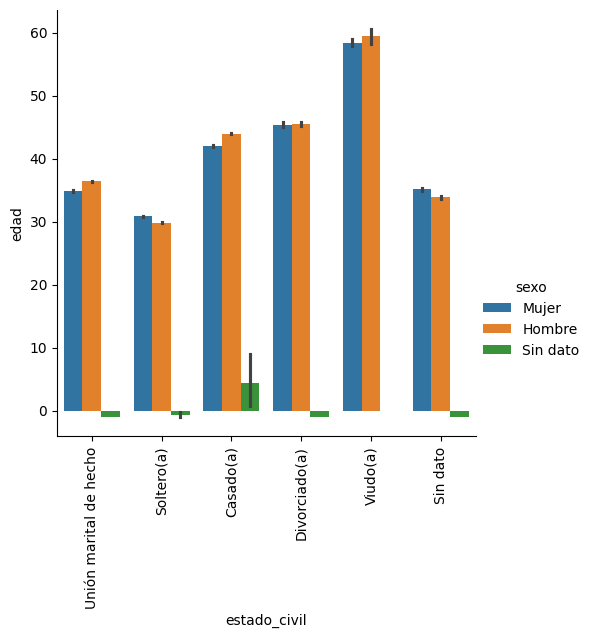

In [26]:
#grafico sin apilar categorias
sns.catplot(data=df_hurto_personas, x="estado_civil", y="edad", hue="sexo", kind="bar")
plt.xticks(rotation=90)
plt.show()

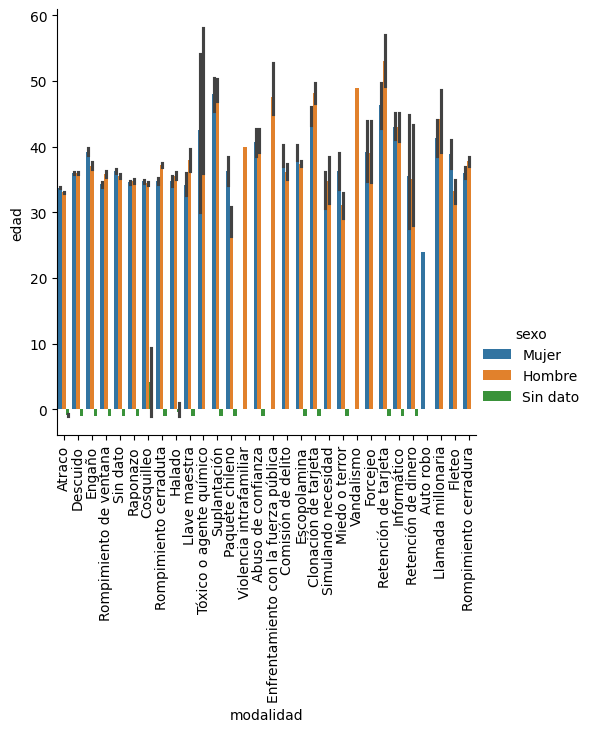

In [34]:
#grafico sin apilar categoriaS
sns.catplot(data=df_hurto_personas, x="modalidad", y="edad", hue="sexo", kind="bar")
plt.xticks(rotation=90)
plt.show()